
# RNN 古诗生成（LSTM）

本实验基于 PyTorch 实现一个 LSTM 古诗生成模型。

## 功能
- 自动读取当前目录下的四个 json 数据集：
  - poet.song.40000.json
  - poet.song.41000.json
  - poet.song.42000.json
  - poet.song.43000.json
- 自动筛选七言绝句
- 使用 LSTM 训练古诗生成模型
- 绘制 Loss 曲线
- 根据“明月”生成古诗

请确保：
1. 四个 json 文件与本 notebook 在同一目录下
2. 已安装 pytorch、matplotlib、tqdm


In [1]:

import json
import os
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu



## 1. 数据读取与预处理


In [2]:

json_files = [
    "poet.song.40000.json",
    "poet.song.41000.json",
    "poet.song.42000.json",
    "poet.song.43000.json"
]

poems = []

for file in json_files:
    if not os.path.exists(file):
        print(f"文件不存在: {file}")
        continue

    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)

    for item in data:

        if "paragraphs" not in item:
            continue

        paragraphs = item["paragraphs"]

        # 直接拼接，不筛选格式
        poem = "".join(paragraphs)

        # 去除太短文本
        if len(poem) > 20:
            poems.append(poem)

print("七言绝句数量:", len(poems))
print(poems[:3])


七言绝句数量: 3915
['於道無所證，方通萬法路。或明或暗行，不慎亦不護。月來松色寒，雲去青山露。今古天台橋，幾人能得度。', '輕輕人問玄中旨，便吐肝腸說與他。木人暗皺雙眉處，石女多言爭奈何。', '雙盲入暗路崎嶇，日落棲蘆暫得甦。爭似石人眠半夜，免教舜讓守休居。須知花綻非干木，無腳行時早觸途。昨朝風起長安道，元是崑崙進國圖。']



## 2. 构建词表


In [3]:

all_text = "".join(poems)

vocab = sorted(list(set(all_text)))
word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for w,i in word2idx.items()}

vocab_size = len(vocab)

print("词表大小:", vocab_size)


词表大小: 5743



## 3. 数据集构建


In [4]:

sequence_length = 20

class PoetryDataset(Dataset):
    def __init__(self, poems):
        self.data = []

        for poem in poems:
            encoded = [word2idx[c] for c in poem]

            for i in range(len(encoded) - sequence_length):
                x = encoded[i:i+sequence_length]
                y = encoded[i+1:i+sequence_length+1]

                self.data.append((x, y))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x, y = self.data[idx]

        return (
            torch.tensor(x, dtype=torch.long),
            torch.tensor(y, dtype=torch.long)
        )

dataset = PoetryDataset(poems)

loader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

print("训练样本数:", len(dataset))


训练样本数: 208168



## 4. 构建 LSTM 网络


In [5]:

class PoetryModel(nn.Module):
    def __init__(self, vocab_size, embed_size=64, hidden_size=128, num_layers=1):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_size)

        self.lstm = nn.LSTM(
            input_size=embed_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):

        x = self.embedding(x)

        output, hidden = self.lstm(x, hidden)

        output = self.fc(output)

        return output, hidden

model = PoetryModel(vocab_size).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)


PoetryModel(
  (embedding): Embedding(5743, 64)
  (lstm): LSTM(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=5743, bias=True)
)



## 5. 模型训练


In [6]:

epochs = 10

loss_history = []

for epoch in range(epochs):

    model.train()

    total_loss = 0

    loop = tqdm(loader)

    for x, y in loop:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        output, _ = model(x)

        loss = criterion(
            output.reshape(-1, vocab_size),
            y.reshape(-1)
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        loop.set_description(f"Epoch [{epoch+1}/{epochs}]")
        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(loader)

    loss_history.append(avg_loss)

    print(f"Epoch {epoch+1}, Loss = {avg_loss:.4f}")


Epoch [1/10]: 100%|█████████████████████████████████████████████████████| 1627/1627 [04:01<00:00,  6.74it/s, loss=5.59]


Epoch 1, Loss = 6.2761


Epoch [2/10]: 100%|█████████████████████████████████████████████████████| 1627/1627 [04:02<00:00,  6.72it/s, loss=5.14]


Epoch 2, Loss = 5.4397


Epoch [3/10]: 100%|██████████████████████████████████████████████████████| 1627/1627 [04:01<00:00,  6.74it/s, loss=4.9]


...

Epoch 8, Loss = 4.1146


Epoch [9/10]: 100%|█████████████████████████████████████████████████████| 1627/1627 [04:02<00:00,  6.72it/s, loss=4.01]


Epoch 9, Loss = 4.0023


Epoch [10/10]: 100%|████████████████████████████████████████████████████| 1627/1627 [04:03<00:00,  6.68it/s, loss=3.93]

Epoch 10, Loss = 3.9030



## 6. Loss 曲线


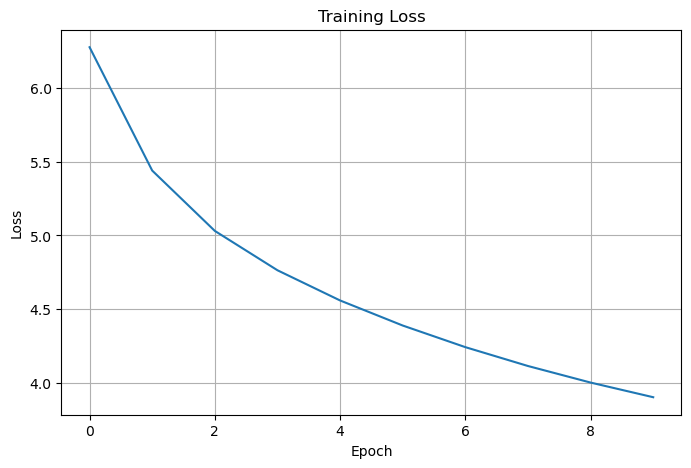

In [7]:

plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.grid(True)

plt.show()



## 7. 古诗生成


In [21]:
def generate_poem(start_words="明月", max_len=32):
    model.eval()
    generated = list(start_words)
    hidden = None
    
    # 定义所有可能出现在数据集里的标点，防止漏网之鱼
    punctuation = ["，", "。", "？", "！", ",", ".", " ", "；", ";"]

    # 1. 预热模型
    for word in start_words:
        input_seq = torch.tensor([[word2idx[word]]], dtype=torch.long).to(device)
        output, hidden = model(input_seq, hidden)

    current_word = start_words[-1]
    
    # 2. 开始生成（七言绝句总长固定为 32 字符：7字+1标点 * 4句）
    for i in range(max_len - len(start_words)):
        input_seq = torch.tensor([[word2idx[current_word]]], dtype=torch.long).to(device)
        output, hidden = model(input_seq, hidden)

        logits = output[0, -1, :]
        current_pos = len(generated) + 1  # 当前正在生成的字在整首诗中的位置

        # --- 强制格式逻辑 ---
        if current_pos % 8 == 0:
            # 到了标点位：强制输出逗号或句号
            next_word = "。" if current_pos % 16 == 0 else "，"
        else:
            # 到了文字位：强制不许输出标点
            probs = torch.softmax(logits / 0.8, dim=-1)
            next_id = torch.multinomial(probs, 1).item()
            next_word = idx2word[next_id]
            
            # 如果模型在文字位输出了标点，循环寻找直到找到一个非标点字
            attempts = 0
            while next_word in punctuation and attempts < 10:
                # 采样概率前 10 中排除标点后的最优选
                next_id = torch.topk(logits, 10)[1][attempts + 1].item()
                next_word = idx2word[next_id]
                attempts += 1
        # ------------------

        generated.append(next_word)
        current_word = next_word

        if generated.count("。") >= 2:
            break

    return "".join(generated)

print(generate_poem("明月"))

明月華雄奇絕誅，烹妙不能逃然樂。江南還白日月近，閒帳一堠遥相逢。



## 8. 保存模型（可选）


In [19]:

torch.save(model.state_dict(), "poetry_lstm.pth")

print("模型已保存")


模型已保存
